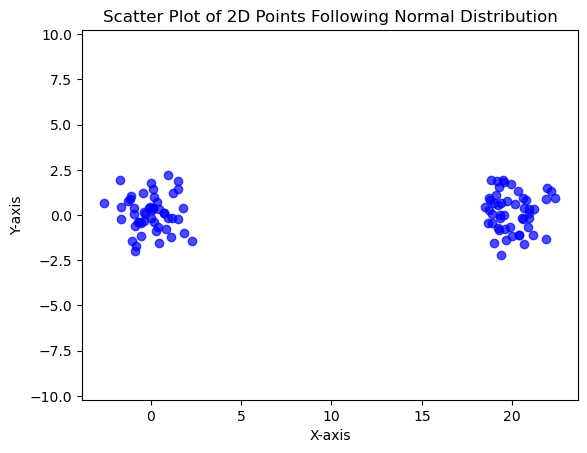

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)  # Seed for reproducibility
# Parameters
mean = [0, 0]  # Mean for x and y
std_dev = [1, 1]  # Standard deviation for x and y
num_points_per_cluster = 50  # Number of points to generate

# Generate points
points1 = np.random.normal(loc=[0, 0], scale=std_dev, size=(num_points_per_cluster, 2))
points3 = np.random.normal(loc=[20, 0], scale=std_dev, size=(num_points_per_cluster, 2))
X = np.vstack([points1, points3])

# Scatter plot
plt.scatter(X[:, 0], X[:, 1], alpha=0.7, color="blue")
plt.title("Scatter Plot of 2D Points Following Normal Distribution")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
# plt.grid()
plt.axis("equal")  # Ensure equal scaling
plt.show()

In [ ]:
import graph_mph

# build a bi-filtration from a point cloud
bifi = graph_mph.BiFiltration(
    filtration_type="degree",  # filtration type can be "degree", "degree_rational", "ball_density", "ball_density_rational", "firep"
    points=X,
)

graded_graph = bifi.ggraph
res = graph_mph.compute_MPH0(graded_graph)

In [3]:
table_x_coords = bifi.get_x_coords()
table_y_coords = bifi.get_y_coords()

In [4]:
def convert_betti_numbers_to_2d_array(
    betti_numbers: list[tuple[int, int]],
    m: int,
    n: int,
):
    """
    Convert the Betti numbers to a 2D array.

    - betti_numbers: list of betti numbers' indices, e.g., [(0, 0), (0, 1), (1, 0), (1, 1)]
    - m: number of rows in the Betti table
    - n: number of columns in the Betti table
    """
    betti_array = np.zeros((m, n), dtype=np.int32)
    for betti_number in betti_numbers:
        x, y = betti_number  # x, y is the coordinate index
        betti_array[x][y] += 1
    return betti_array


def compute_Hilbert_matrix(absolute_betti_numbers_result_dict, m, n):
    """
    Compute the Hilbert function in matrix form from the absolute betti numbers.
    Note it is not an ideal choice to visualize because the size of m, n is too large.
    Args:
        - absolute_betti_numbers_result_dict: a dictionary of absolute betti numbers,
        e.g., {"b_0": [(0, 0), (0, 1), (1, 0), (1, 1)], "b_1": [(0, 0), (0, 1), (1, 0), (1, 1)], "b_2": [(0, 0), (0, 1), (1, 0), (1, 1)]}
        - m: number of rows in the Betti table
        - n: number of columns in the Betti table
    Returns:
        Hilbert_matrix: a 2D array of the Hilbert matrix
    """
    b_0_array = convert_betti_numbers_to_2d_array(
        absolute_betti_numbers_result_dict["b_0"], m, n
    )
    b_1_array = convert_betti_numbers_to_2d_array(
        absolute_betti_numbers_result_dict["b_1"], m, n
    )
    b_2_array = convert_betti_numbers_to_2d_array(
        absolute_betti_numbers_result_dict["b_2"], m, n
    )

    return b_0_array - b_1_array + b_2_array


m, n = len(table_x_coords), len(table_y_coords)
# here is the Hilbert matrix
Hibert_matrix = compute_Hilbert_matrix(res, m, n)

In [5]:
Hibert_matrix

array([[  0,   0,   0, ...,   0,   0, 100],
       [  0,   0,   0, ...,   0,   1,  -2],
       [  0,   0,   0, ...,   0,   1,  -2],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=int32)

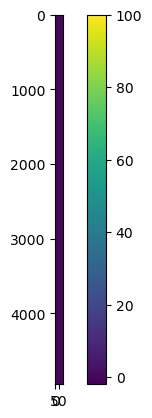

In [6]:
import matplotlib.pyplot as plt

plt.imshow(Hibert_matrix)
plt.colorbar()
plt.show()

In [7]:
m, n

(4951, 100)

It is very hard to visualize due to the size of m = 4951, n = 100. Let's merge the x axis. 

In [8]:
def map_graded_betti_numbers_to_filtration_values(
    graded_betti_numbers: list[tuple[int, int]],
    filtration_values_x: list[float],
    filtration_values_y: list[float],
):
    """
    Map the graded betti numbers to the filtration values.

    Args:
        graded_betti_numbers: list of graded betti numbers
        filtration_values_x: list of filtration values in x coordinate
        filtration_values_y: list of filtration values in y coordinate
    Returns:
        graded_betti_numbers_in_filtration_values: list of graded betti numbers in filtration values
    """
    graded_betti_numbers_in_filtration_values = []
    for betti_number in graded_betti_numbers:
        x, y = (
            betti_number  # x, y is the index of the betti number in the filtration_values_x and filtration_values_y
        )
        graded_betti_numbers_in_filtration_values.append(
            (filtration_values_x[x], filtration_values_y[y])
        )
    return graded_betti_numbers_in_filtration_values


def compute_approximated_Hilbert_matrix(
    matrix_shape: tuple[int, int],
    row_range: tuple[float, float],
    column_range: tuple[float, float],
    betti0s: np.ndarray,
    betti1s: np.ndarray,
    betti2s: np.ndarray,
):
    """
    Compute the approximated Hilbert function (dimension of H_0) on a pre-defined grid.
    The formula is: H_0(s, k) = b_0(s, k) - b_1(s, k) + b_2(s, k)
    Args:
        matrix_shape (tuple): the shape of the matrix
        row_range (tuple): row value range
        column_range (tuple): column value range
        betti0s (2D np.ndarray ): betti0s, each row is a betti number in the format of (s, k)
        betti1s (2D np.ndarray): betti1s, each row is a betti number
        betti2s (2D np.ndarray): betti2s, each row is a betti number
    Returns:
        H0_values (np.ndarray): H_0 values
    """
    m, n = matrix_shape
    # setup the meshgrid
    xs = np.linspace(row_range[0], row_range[1], m)
    ys = np.linspace(column_range[0], column_range[1], n)
    H0_meshgrid = np.meshgrid(xs, ys, indexing="ij")

    # loop over the meshgrid to compute the H_0 value
    H0_values = np.zeros((m, n), dtype=np.int32)
    for i in range(m):
        for j in range(n):
            s, k = H0_meshgrid[0][i][j], H0_meshgrid[1][i][j]
            b0 = np.sum((betti0s[:, 0] <= s) & (betti0s[:, 1] <= k))
            b1 = np.sum((betti1s[:, 0] <= s) & (betti1s[:, 1] <= k))
            b2 = np.sum((betti2s[:, 0] <= s) & (betti2s[:, 1] <= k))
            H0_values[i][j] = b0 - b1 + b2
    return H0_values


In [9]:
import matplotlib.colors as mcolors


def draw_discrete_matrix(
    mat, x_axis_range=None, y_axis_range=None, origin="upper", discrete_colorbar=True
):
    """
    Draw the discrete matrix.

    Args:
        mat (np.ndarray): the matrix to draw
        x_axis_range (tuple): the range of the x axis
        y_axis_range (tuple): the range of the y axis
        origin (str): the origin of the matrix
        discrete_colorbar (bool): whether to draw the discrete color bar
    Returns:
        plt: the plot
        cbar: the color bar
    """
    # Define the boundaries for the discrete color bar
    boundaries = np.arange(np.min(mat), np.max(mat) + 2) - 0.5
    norm = mcolors.BoundaryNorm(boundaries, plt.cm.viridis.N)

    # Plot the H_0 values with discrete color bar
    if (
        x_axis_range is None or y_axis_range is None
    ):  # if no range is provided, use the default range
        plt.imshow(mat, origin=origin, aspect="auto", norm=norm, cmap="viridis")
    else:  # if range is provided, use the provided range
        plt.imshow(
            mat,
            extent=(*x_axis_range, *y_axis_range),
            origin=origin,
            aspect="auto",
            norm=norm,
            cmap="viridis",
        )

    if discrete_colorbar:
        cbar = plt.colorbar(ticks=np.arange(np.min(mat), np.max(mat) + 1))
    else:
        cbar = plt.colorbar()
    cbar.set_label("$H_0$ values")
    return plt

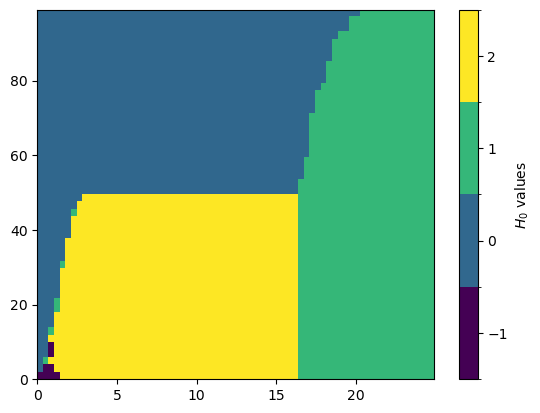

In [10]:
# convert the graded betti numbers in indices to filtration values
graded_betti_numbers_in_filtration_values = {}
for name in ["b_0", "b_1", "b_2"]:
    graded_betti_numbers_in_filtration_values[name] = (
        map_graded_betti_numbers_to_filtration_values(
            res[name], table_x_coords, table_y_coords
        )
    )

# compute the H_0 values on a grid
H_0_values = compute_approximated_Hilbert_matrix(
    matrix_shape=(70, 50),
    row_range=(np.min(table_x_coords), np.max(table_x_coords)),
    column_range=(np.min(table_y_coords), np.max(table_y_coords)),
    betti0s=np.array(graded_betti_numbers_in_filtration_values["b_0"]),
    betti1s=np.array(graded_betti_numbers_in_filtration_values["b_1"]),
    betti2s=np.array(graded_betti_numbers_in_filtration_values["b_2"]),
)


# mask the H_0 values that are less than 3
H_0_values_masked = np.where(H_0_values >= 3, -1, H_0_values)

# when drawing in Eucledian space, the matrix should be transposed
H_0_values_masked = H_0_values_masked.T

# reverse the degree axis
H_0_values_masked = np.flip(H_0_values_masked, axis=0)

# draw the H_0 values
discrete_plot = draw_discrete_matrix(
    H_0_values_masked,
    x_axis_range=(np.min(table_x_coords), np.max(table_x_coords)),
    y_axis_range=(-np.max(table_y_coords), -np.min(table_y_coords)),
    discrete_colorbar=True,
    origin="lower",
)
discrete_plot.show()


## Let's visualize the betti numbers of Figure one

In [ ]:
# build a bi-filtration from a point cloud
bifi = graph_mph.BiFiltration(
    filtration_type="firep",  # filtration type can be "degree", "degree_rational", "ball_density", "ball_density_rational", "firep"
    path="figure1_data.firep",
)

graded_graph = bifi.ggraph
res = graph_mph.compute_MPH0(graded_graph)

In [12]:
res

{'b_0': [(1, 3), (2, 1)],
 'b_1': [(3, 5), (5, 3)],
 'b_2': [(5, 5)],
 'b_0_1': [(5, 5), (6, 2), (6, 6)],
 'M': [(1, 1, -1), (2, 1, 1), (1, 2, -1), (2, 2, 1)]}

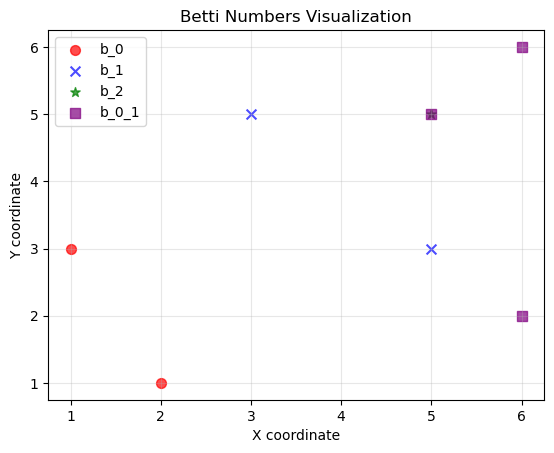

In [13]:
import matplotlib.pyplot as plt

# Define shapes for different Betti numbers
shapes = {
    "b_0": "o",  # circle
    "b_1": "x",  # cross
    "b_2": "*",  # star
    "b_0_1": "s",  # square
}

colors = {
    "b_0": "red",
    "b_1": "blue",
    "b_2": "green",
    "b_0_1": "purple",
}

# Plot the betti numbers with different shapes and colors
for name in ["b_0", "b_1", "b_2", "b_0_1"]:
    betti_numbers = np.array(res[name])
    plt.scatter(
        betti_numbers[:, 0],
        betti_numbers[:, 1],
        c=colors[name],
        marker=shapes[name],
        s=50,
        alpha=0.7,
        label=name,
    )

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Betti Numbers Visualization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
